In [20]:
# Import Libraries
!pip install emoji
!pip install tqdm
import pandas as pd
import numpy as np
import re
import string
import emoji

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from collections import Counter

import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem.isri import ISRIStemmer

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [22]:
# Load files
neg_train = pd.read_csv("train_Arabic_tweets_negative_20190413.tsv", sep='\t', header=None)
pos_train = pd.read_csv("train_Arabic_tweets_positive_20190413.tsv", sep='\t', header=None)
pos_test = pd.read_csv("test_Arabic_tweets_positive_20190413.tsv", sep='\t', header=None)
neg_test = pd.read_csv("test_Arabic_tweets_negative_20190413.tsv", sep='\t', header=None)



In [23]:
train_df = (
    pd.concat([pos_train, neg_train], ignore_index=True)
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

test_df = (
    pd.concat([pos_test, neg_test], ignore_index=True)
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

In [24]:
for df in [train_df, test_df]:
    df.columns = ['label', 'tweet']

In [25]:
df.shape

(11520, 2)

<Axes: xlabel='label', ylabel='count'>

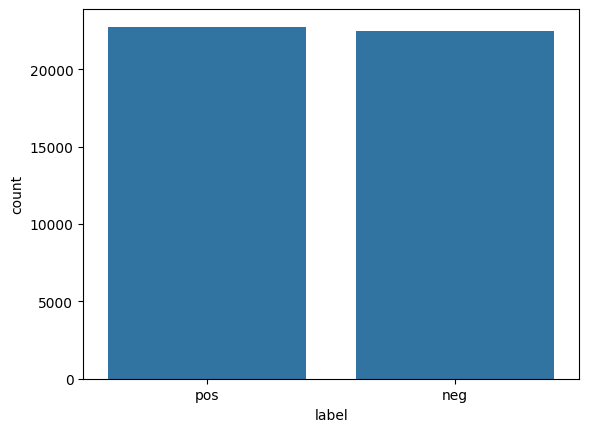

In [26]:
sns.countplot(data=train_df,x='label')

In [27]:

emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emotions
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F1E0-\U0001F1FF"  # flags
    "\U00002700-\U000027BF"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE
)

def extract_emojis(text):
    return emoji_pattern.findall(str(text))

In [28]:
train_df["emojies"] = train_df["tweet"].apply(extract_emojis)

In [29]:
train_df.head(5)

,label,tweet,emojies
0,pos,مقال يدور حول الحمى يوشك ان يقع فيه 😊,[😊]
1,pos,تيشرت القائد 💙,[💙]
2,neg,وكل السعوديه بدو ..حتى الحاضره منهم من اصل بدو...,[😩]
3,neg,المونافري طلع برهوش .. سدينا 😤,[😤]
4,neg,منو خر بيتهم مثلنا 😩,[😩]


In [30]:
from tqdm.auto import tqdm
tqdm.pandas()

exclude=[string.punctuation]
exclude.append('﴾')
exclude.append('﴿')
exclude.append('؟')
def remove_punc(text):
  for char in exclude:
    text=text.replace(char,'')
  return text

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : remove_punc(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : remove_punc(x))

  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [31]:
train_df.head(5)

,label,tweet,emojies
0,pos,مقال يدور حول الحمى يوشك ان يقع فيه 😊,[😊]
1,pos,تيشرت القائد 💙,[💙]
2,neg,وكل السعوديه بدو ..حتى الحاضره منهم من اصل بدو...,[😩]
3,neg,المونافري طلع برهوش .. سدينا 😤,[😤]
4,neg,منو خر بيتهم مثلنا 😩,[😩]


In [32]:
def remove_digits(text):
  text=re.sub('\w*\d\w*','',text)
  return text

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : remove_digits(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : remove_digits(x))

<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:2: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_3161/1744823745.py:2: SyntaxWarning: invalid escape sequence '\w'
  text=re.sub('\w*\d\w*','',text)


  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [33]:
stopwords=stopwords.words('english')
stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [34]:
def remove_stopwords(text):
  filtered_words=[word for word in text.split() if word not in stopwords]
  return ' '.join(filtered_words)

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : remove_stopwords(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : remove_stopwords(x))


  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [35]:
arabic_StopWords = nltk.corpus.stopwords.words("arabic")
arabic_StopWords

['إذ',
 'إذا',
 'إذما',
 'إذن',
 'أف',
 'أقل',
 'أكثر',
 'ألا',
 'إلا',
 'التي',
 'الذي',
 'الذين',
 'اللاتي',
 'اللائي',
 'اللتان',
 'اللتيا',
 'اللتين',
 'اللذان',
 'اللذين',
 'اللواتي',
 'إلى',
 'إليك',
 'إليكم',
 'إليكما',
 'إليكن',
 'أم',
 'أما',
 'أما',
 'إما',
 'أن',
 'إن',
 'إنا',
 'أنا',
 'أنت',
 'أنتم',
 'أنتما',
 'أنتن',
 'إنما',
 'إنه',
 'أنى',
 'أنى',
 'آه',
 'آها',
 'أو',
 'أولاء',
 'أولئك',
 'أوه',
 'آي',
 'أي',
 'أيها',
 'إي',
 'أين',
 'أين',
 'أينما',
 'إيه',
 'بخ',
 'بس',
 'بعد',
 'بعض',
 'بك',
 'بكم',
 'بكم',
 'بكما',
 'بكن',
 'بل',
 'بلى',
 'بما',
 'بماذا',
 'بمن',
 'بنا',
 'به',
 'بها',
 'بهم',
 'بهما',
 'بهن',
 'بي',
 'بين',
 'بيد',
 'تلك',
 'تلكم',
 'تلكما',
 'ته',
 'تي',
 'تين',
 'تينك',
 'ثم',
 'ثمة',
 'حاشا',
 'حبذا',
 'حتى',
 'حيث',
 'حيثما',
 'حين',
 'خلا',
 'دون',
 'ذا',
 'ذات',
 'ذاك',
 'ذان',
 'ذانك',
 'ذلك',
 'ذلكم',
 'ذلكما',
 'ذلكن',
 'ذه',
 'ذو',
 'ذوا',
 'ذواتا',
 'ذواتي',
 'ذي',
 'ذين',
 'ذينك',
 'ريث',
 'سوف',
 'سوى',
 'شتان',
 'عدا',
 'عسى',
 'عل'

In [36]:
def remove_arabic_stopwords(text):
  filtered_words=[word for word in text.split() if word not in arabic_StopWords]
  return ' '.join(filtered_words)

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : remove_arabic_stopwords(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : remove_arabic_stopwords(x))


  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [37]:

train_df.head(5)

,label,tweet,emojies
0,pos,مقال يدور حول الحمى يوشك ان يقع 😊,[😊]
1,pos,تيشرت القائد 💙,[💙]
2,neg,وكل السعوديه بدو ..حتى الحاضره منهم اصل بدوي 😩...,[😩]
3,neg,المونافري طلع برهوش .. سدينا 😤,[😤]
4,neg,منو خر بيتهم مثلنا 😩,[😩]


In [38]:
!pip install pyarabic
from pyarabic.araby import strip_tashkeel

def clean_arabic_text(text):
    # 1. Remove diacritics (التشكيل)
    text = strip_tashkeel(text)

    # 2. Remove Arabic + English punctuation
    arabic_punct = "،؛؟ـ«»…"
    all_punct = string.punctuation + arabic_punct
    text = text.translate(str.maketrans('', '', all_punct))

    # 3. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

train_df['tweet'] = train_df['tweet'].progress_apply(clean_arabic_text)
test_df['tweet'] = test_df['tweet'].progress_apply(clean_arabic_text)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 4.8 MB/s eta 0:00:00


  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [39]:

def normalize_arabic(text):
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    return text

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : normalize_arabic(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : normalize_arabic(x))

  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [40]:

def repeated_letter(text):
  text = re.sub(r'(.)\1{2,}', r'\1', text)
  return text
train_df['tweet']=train_df['tweet'].progress_apply(lambda x : repeated_letter(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : repeated_letter(x))

  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [41]:
def arabic_english(text):
  text = re.sub(r'[^\u0600-\u06FFa-zA-Z\s]', '', text)
  return text

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : arabic_english(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : arabic_english(x))


  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [42]:
def remove_spaces(text):
  text = re.sub(r'\s+', ' ', text).strip()
  return text

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : remove_spaces(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : remove_spaces(x))


  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

##RNN Implementation

In [43]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [44]:
vocab_size = 20000
tokenizer = Tokenizer(
        num_words=vocab_size,
        oov_token="<OOV>"
)
tokenizer.fit_on_texts(train_df['tweet'])

In [45]:
train_df['text_sequences'] = tokenizer.texts_to_sequences(train_df['tweet'])
test_df['text_sequences'] = tokenizer.texts_to_sequences(test_df['tweet'])

In [46]:
for word, index in tokenizer.word_index.items():
    print(word, index)
    if index == 10:
        break

<OOV> 1
الله 2
اللهم 3
اللي 4
انا 5
والله 6
الهلال 7
ان 8
الخير 9
الي 10


In [47]:
vocab_size = len(tokenizer.word_index)

In [48]:
train_df.head(5)

,label,tweet,emojies,text_sequences
0,pos,مقال يدور حول الحمي يوشك ان يقع,[😊],"[3295, 571, 281, 1, 1, 8, 3888]"
1,pos,تيشرت القايد,[💙],"[16469, 3681]"
2,neg,وكل السعوديه بدو حتي الحاضره منهم اصل بدوي انا...,[😩],"[240, 1476, 4403, 552, 1, 530, 2712, 16470, 5,..."
3,neg,المونافري طلع برهوش سدينا,[😤],"[1, 424, 1, 1]"
4,neg,منو خر بيتهم مثلنا,[😩],"[1292, 1, 16472, 16473]"


In [49]:
# Compute sequence lengths
sequence_lengths = [len(seq) for seq in train_df['text_sequences']]

# Count frequencies of each length
length_counts = Counter(sequence_lengths)

# Prepare data for plotting
lengths = list(length_counts.keys())
counts = list(length_counts.values())

In [50]:
length_counts.most_common(5)

[(3, 3730), (2, 3643), (4, 3430), (5, 2982), (6, 2618)]

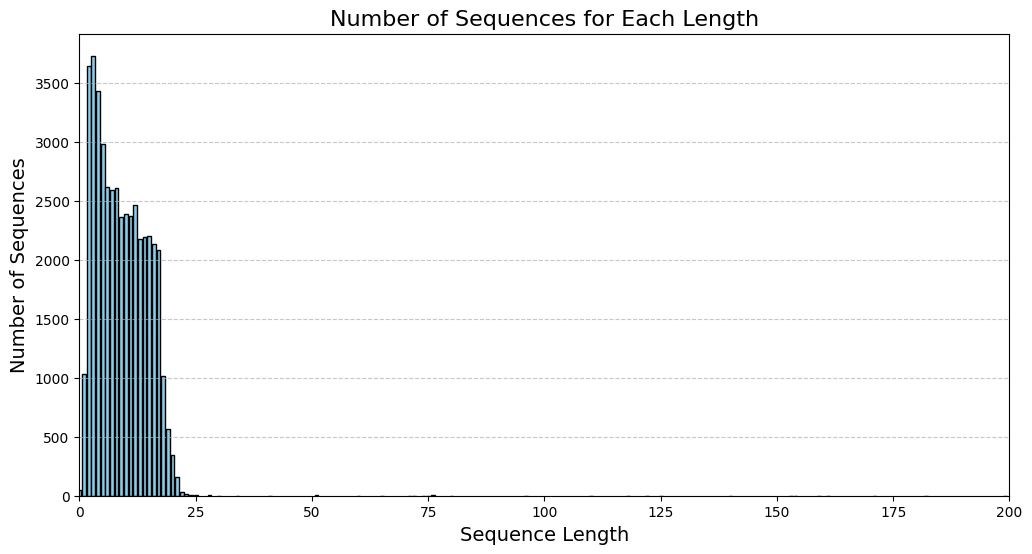

In [51]:
plt.figure(figsize=(12, 6))
plt.bar(lengths, counts, color='skyblue', edgecolor='black')

plt.title('Number of Sequences for Each Length', fontsize=16)
plt.xlabel('Sequence Length', fontsize=14)
plt.ylabel('Number of Sequences', fontsize=14)

plt.xlim(0, 200)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [52]:
input_shape = 25

In [53]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_df['tweet'])

In [54]:
X_train_seq = tokenizer.texts_to_sequences(train_df['tweet'])
X_test_seq = tokenizer.texts_to_sequences(test_df['tweet'])

In [55]:
X_train = pad_sequences(X_train_seq, maxlen=input_shape, padding='post')
X_test = pad_sequences(X_test_seq, maxlen=input_shape, padding='post')

In [56]:
LB = LabelEncoder()
y_train = LB.fit_transform(train_df['label'])
y_test = LB.transform(test_df['label'])

In [57]:
y_train = np.array(y_train, dtype="int32")
y_test = np.array(y_test, dtype="int32")

X_train = np.array(X_train, dtype="int32")
X_test = np.array(X_test, dtype="int32")

In [58]:

model = tf.keras.models.Sequential([

    tf.keras.layers.Input(shape=(input_shape,)),

    tf.keras.layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=128
    ),

    tf.keras.layers.SimpleRNN(64),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [59]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [60]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 25, 128)        │     8,418,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,430,849 (32.16 MB)

 Trainable params: 8,430,849 (32.16 MB)

 Non-trainable params: 0 (0.00 B)

None


In [61]:
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [62]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.6682 - loss: 0.5673
Epoch 1: val_accuracy improved from None to 0.77338, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 79s 133ms/step - accuracy: 0.7191 - loss: 0.5079 - val_accuracy: 0.7734 - val_loss: 0.4327
Epoch 2/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9422 - loss: 0.1526
Epoch 2: val_accuracy did not improve from 0.77338
566/566 ━━━━━━━━━━━━━━━━━━━━ 75s 121ms/step - accuracy: 0.9371 - loss: 0.1588 - val_accuracy: 0.7632 - val_loss: 0.5206
Epoch 3/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9736 - loss: 0.0697
Epoch 3: val_accuracy did not improve from 0.77338
566/566 ━━━━━━━━━━━━━━━━━━━━ 68s 121ms/step - accuracy: 0.9722 - loss: 0.0717 - val_accuracy: 0.7567 - val_loss: 0.6117
Epoch 4/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9801 - loss: 0.0498
Epoch 4: val_accuracy did not improve from 0

In [63]:
best_model = tf.keras.models.load_model("best_model.keras")

In [64]:

y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.4).astype(int).flatten()

print(
    classification_report(
        y_test,
        y_pred,
        target_names=LB.classes_
    )
)

360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

         neg       0.80      0.68      0.74      5768
         pos       0.72      0.83      0.77      5752

    accuracy                           0.76     11520
   macro avg       0.76      0.76      0.75     11520
weighted avg       0.76      0.76      0.75     11520



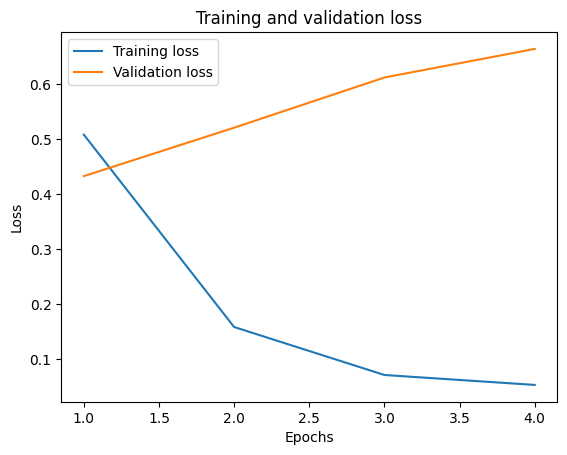

In [65]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

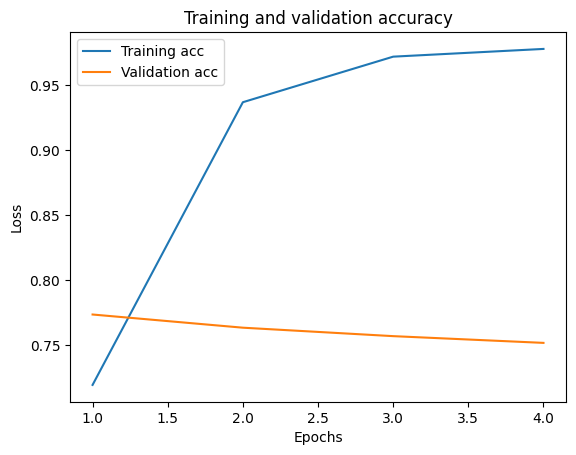

In [66]:

plt.clf()
acc_values = history.history['accuracy']
val_acc_values = history.history['val_accuracy']

plt.plot(epochs, acc, label='Training acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [67]:
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.7557291666666667


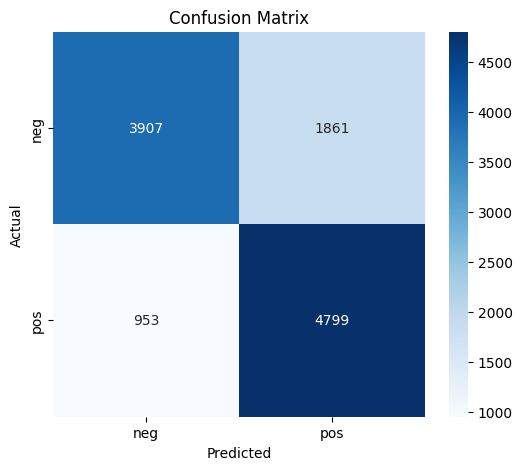

In [68]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LB.classes_,
    yticklabels=LB.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [69]:
# Test new Sentences
new_text = [
    "الخدمة ممتازة جدا جدا",
    "سيئة للغاية ولن أكرر التجربة مرة أخرى",
    "التجربة كانت عادية"
]

seq = tokenizer.texts_to_sequences(new_text)
padded = pad_sequences(seq, maxlen=input_shape, padding='post')

pred = model.predict(padded)
pred_classes = (pred > 0.5).astype(int).flatten()

results = LB.inverse_transform(pred_classes)

for text, label in zip(new_text, results):
    print(text, " ---> ", label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
الخدمة ممتازة جدا جدا  --->  pos
سيئة للغاية ولن أكرر التجربة مرة أخرى  --->  neg
التجربة كانت عادية  --->  pos


## Word2Vec Embeddings

In [70]:
# Install Gensim for Word2Vec
!pip install gensim

In [71]:
from gensim.models import Word2Vec

# Prepare text data for Word2Vec training
# Convert tweets to lists of words
word2vec_sentences_train = [tweet.split() for tweet in train_df['tweet']]
word2vec_sentences_test = [tweet.split() for tweet in test_df['tweet']]

# Combine for training Word2Vec
all_word2vec_sentences = word2vec_sentences_train + word2vec_sentences_test

# Train Word2Vec model
# Parameters: vector_size is the dimensionality of the word vectors
# window is the maximum distance between the current and predicted word within a sentence
# min_count is the minimum frequency of words to consider
# workers is the number of CPU cores to use
word2vec_model = Word2Vec(
    sentences=all_word2vec_sentences,
    vector_size=100, # Embedding dimension
    window=5,
    min_count=1,
    workers=4
)

# Create an embedding matrix
embedding_dim = 100 # Must match vector_size above
word_index = tokenizer.word_index # Re-use the tokenizer from previous steps

word2vec_embedding_matrix = np.zeros((vocab_size + 1, embedding_dim))
for word, i in word_index.items():
    if i > vocab_size: # Ensure we don't go out of bounds for current vocab_size
        continue
    try:
        word2vec_embedding_matrix[i] = word2vec_model.wv[word]
    except KeyError:
        # Words not found in the embedding model will be all zeros
        pass

print(f"Word2Vec embedding matrix shape: {word2vec_embedding_matrix.shape}")

Word2Vec embedding matrix shape: (65769, 100)


### Word2Vec + Simple RNN

In [72]:
model_w2v_rnn = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(input_shape,)),
    tf.keras.layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=embedding_dim,
        weights=[word2vec_embedding_matrix],
        trainable=False # Set to False to use pre-trained embeddings as-is
    ),
    tf.keras.layers.SimpleRNN(64),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_w2v_rnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print(model_w2v_rnn.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 25, 100)        │     6,576,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,587,525 (25.13 MB)

 Trainable params: 10,625 (41.50 KB)

 Non-trainable params: 6,576,900 (25.09 MB)

None


In [73]:
checkpoint_w2v_rnn = ModelCheckpoint(
    "best_model_w2v_rnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop_w2v_rnn = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_w2v_rnn = model_w2v_rnn.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint_w2v_rnn, early_stop_w2v_rnn]
)

Epoch 1/100
563/566 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6207 - loss: 0.6509
Epoch 1: val_accuracy improved from None to 0.65422, saving model to best_model_w2v_rnn.keras

Epoch 1: finished saving model to best_model_w2v_rnn.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.6342 - loss: 0.6398 - val_accuracy: 0.6542 - val_loss: 0.6159
Epoch 2/100
561/566 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6442 - loss: 0.6213
Epoch 2: val_accuracy did not improve from 0.65422
566/566 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.6470 - loss: 0.6180 - val_accuracy: 0.6438 - val_loss: 0.6086
Epoch 3/100
559/566 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6519 - loss: 0.6047 
Epoch 3: val_accuracy did not improve from 0.65422
566/566 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6523 - loss: 0.6058 - val_accuracy: 0.6512 - val_loss: 0.6038
Epoch 4/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6587 - loss: 0.5980
Epoch 4: val_accuracy improved from 0

In [74]:
best_model_w2v_rnn = tf.keras.models.load_model("best_model_w2v_rnn.keras")

y_pred_prob_w2v_rnn = best_model_w2v_rnn.predict(X_test)
y_pred_w2v_rnn = (y_pred_prob_w2v_rnn > 0.5).astype(int).flatten()

print("Word2Vec + Simple RNN Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_w2v_rnn,
        target_names=LB.classes_
    )
)

print("Word2Vec + Simple RNN Test Accuracy:", accuracy_score(y_test, y_pred_w2v_rnn))

360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Word2Vec + Simple RNN Classification Report:
              precision    recall  f1-score   support

         neg       0.68      0.74      0.71      5768
         pos       0.71      0.65      0.68      5752

    accuracy                           0.70     11520
   macro avg       0.70      0.70      0.70     11520
weighted avg       0.70      0.70      0.70     11520

Word2Vec + Simple RNN Test Accuracy: 0.6956597222222223


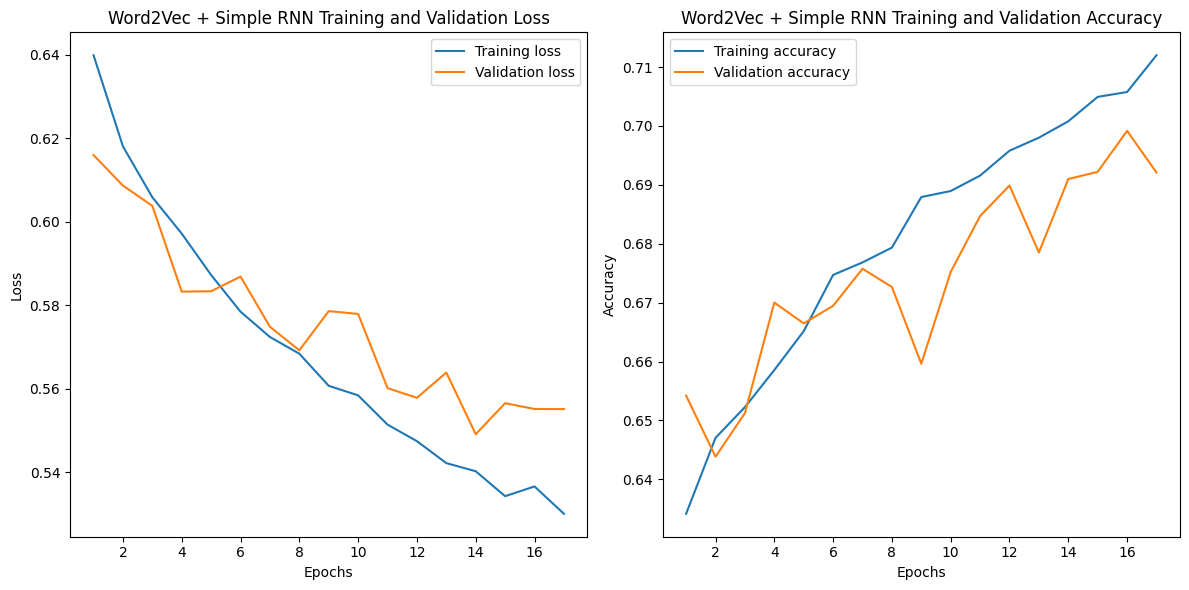

In [75]:
acc_w2v_rnn = history_w2v_rnn.history['accuracy']
val_acc_w2v_rnn = history_w2v_rnn.history['val_accuracy']
loss_w2v_rnn = history_w2v_rnn.history['loss']
val_loss_w2v_rnn = history_w2v_rnn.history['val_loss']

epochs_w2v_rnn = range(1, len(acc_w2v_rnn) + 1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_w2v_rnn, loss_w2v_rnn, label='Training loss')
plt.plot(epochs_w2v_rnn, val_loss_w2v_rnn, label='Validation loss')
plt.title('Word2Vec + Simple RNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_w2v_rnn, acc_w2v_rnn, label='Training accuracy')
plt.plot(epochs_w2v_rnn, val_acc_w2v_rnn, label='Validation accuracy')
plt.title('Word2Vec + Simple RNN Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

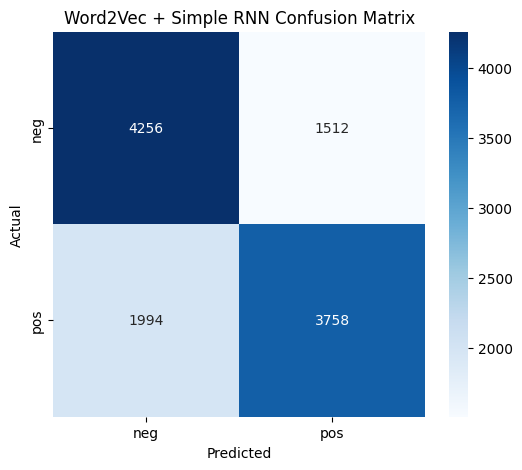

In [76]:
cm_w2v_rnn = confusion_matrix(y_test, y_pred_w2v_rnn)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_w2v_rnn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LB.classes_,
    yticklabels=LB.classes_
)

plt.title("Word2Vec + Simple RNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Word2Vec + LSTM

In [77]:
model_w2v_lstm = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(input_shape,)),
    tf.keras.layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=embedding_dim,
        weights=[word2vec_embedding_matrix],
        trainable=False
    ),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_w2v_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print(model_w2v_lstm.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 25, 100)        │     6,576,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,619,205 (25.25 MB)

 Trainable params: 42,305 (165.25 KB)

 Non-trainable params: 6,576,900 (25.09 MB)

None


In [78]:
checkpoint_w2v_lstm = ModelCheckpoint(
    "best_model_w2v_lstm.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop_w2v_lstm = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_w2v_lstm = model_w2v_lstm.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint_w2v_lstm, early_stop_w2v_lstm]
)

Epoch 1/100
565/566 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6331 - loss: 0.6343
Epoch 1: val_accuracy improved from None to 0.66372, saving model to best_model_w2v_lstm.keras

Epoch 1: finished saving model to best_model_w2v_lstm.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.6479 - loss: 0.6161 - val_accuracy: 0.6637 - val_loss: 0.5947
Epoch 2/100
564/566 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6647 - loss: 0.5871
Epoch 2: val_accuracy improved from 0.66372 to 0.67874, saving model to best_model_w2v_lstm.keras

Epoch 2: finished saving model to best_model_w2v_lstm.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.6649 - loss: 0.5855 - val_accuracy: 0.6787 - val_loss: 0.5714
Epoch 3/100
565/566 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6693 - loss: 0.5751
Epoch 3: val_accuracy improved from 0.67874 to 0.67929, saving model to best_model_w2v_lstm.keras

Epoch 3: finished saving model to best_model_w2v_lstm.keras
566/566 ━━━━━━━━━━━━━━━━

In [79]:
best_model_w2v_lstm = tf.keras.models.load_model("best_model_w2v_lstm.keras")

y_pred_prob_w2v_lstm = best_model_w2v_lstm.predict(X_test)
y_pred_w2v_lstm = (y_pred_prob_w2v_lstm > 0.5).astype(int).flatten()

print("Word2Vec + LSTM Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_w2v_lstm,
        target_names=LB.classes_
    )
)

print("Word2Vec + LSTM Test Accuracy:", accuracy_score(y_test, y_pred_w2v_lstm))

360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Word2Vec + LSTM Classification Report:
              precision    recall  f1-score   support

         neg       0.67      0.85      0.75      5768
         pos       0.79      0.58      0.67      5752

    accuracy                           0.72     11520
   macro avg       0.73      0.71      0.71     11520
weighted avg       0.73      0.72      0.71     11520

Word2Vec + LSTM Test Accuracy: 0.7150173611111111


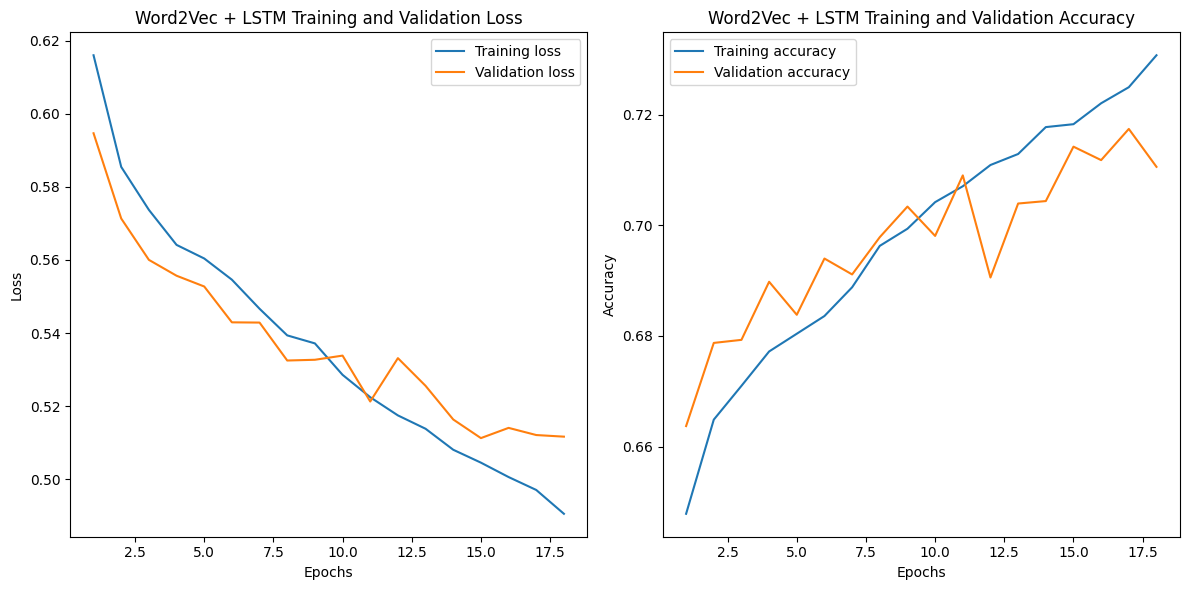

In [80]:
acc_w2v_lstm = history_w2v_lstm.history['accuracy']
val_acc_w2v_lstm = history_w2v_lstm.history['val_accuracy']
loss_w2v_lstm = history_w2v_lstm.history['loss']
val_loss_w2v_lstm = history_w2v_lstm.history['val_loss']

epochs_w2v_lstm = range(1, len(acc_w2v_lstm) + 1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_w2v_lstm, loss_w2v_lstm, label='Training loss')
plt.plot(epochs_w2v_lstm, val_loss_w2v_lstm, label='Validation loss')
plt.title('Word2Vec + LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_w2v_lstm, acc_w2v_lstm, label='Training accuracy')
plt.plot(epochs_w2v_lstm, val_acc_w2v_lstm, label='Validation accuracy')
plt.title('Word2Vec + LSTM Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

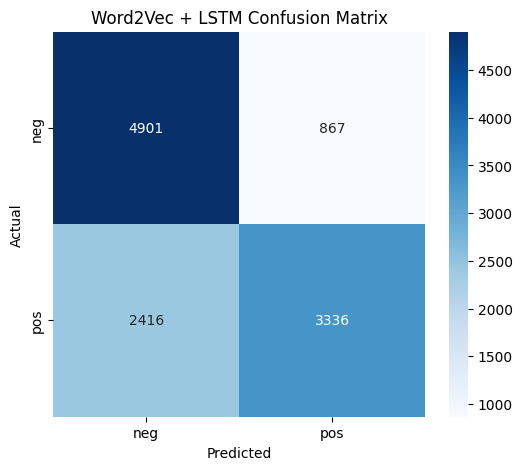

In [81]:
cm_w2v_lstm = confusion_matrix(y_test, y_pred_w2v_lstm)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_w2v_lstm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LB.classes_,
    yticklabels=LB.classes_
)

plt.title("Word2Vec + LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Word2Vec + GRU

In [82]:
model_w2v_gru = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(input_shape,)),
    tf.keras.layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=embedding_dim,
        weights=[word2vec_embedding_matrix],
        trainable=False
    ),
    tf.keras.layers.GRU(64),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_w2v_gru.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print(model_w2v_gru.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 25, 100)        │     6,576,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        31,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,608,837 (25.21 MB)

 Trainable params: 31,937 (124.75 KB)

 Non-trainable params: 6,576,900 (25.09 MB)

None


In [83]:
checkpoint_w2v_gru = ModelCheckpoint(
    "best_model_w2v_gru.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop_w2v_gru = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_w2v_gru = model_w2v_gru.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint_w2v_gru, early_stop_w2v_gru]
)

Epoch 1/100
565/566 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5966 - loss: 0.6557
Epoch 1: val_accuracy improved from None to 0.64716, saving model to best_model_w2v_gru.keras

Epoch 1: finished saving model to best_model_w2v_gru.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.6327 - loss: 0.6316 - val_accuracy: 0.6472 - val_loss: 0.6057
Epoch 2/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6609 - loss: 0.5956
Epoch 2: val_accuracy improved from 0.64716 to 0.66483, saving model to best_model_w2v_gru.keras

Epoch 2: finished saving model to best_model_w2v_gru.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.6610 - loss: 0.5941 - val_accuracy: 0.6648 - val_loss: 0.5773
Epoch 3/100
565/566 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6704 - loss: 0.5791
Epoch 3: val_accuracy improved from 0.66483 to 0.68437, saving model to best_model_w2v_gru.keras

Epoch 3: finished saving model to best_model_w2v_gru.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 2

In [84]:
best_model_w2v_gru = tf.keras.models.load_model("best_model_w2v_gru.keras")

y_pred_prob_w2v_gru = best_model_w2v_gru.predict(X_test)
y_pred_w2v_gru = (y_pred_prob_w2v_gru > 0.5).astype(int).flatten()

print("Word2Vec + GRU Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_w2v_gru,
        target_names=LB.classes_
    )
)

print("Word2Vec + GRU Test Accuracy:", accuracy_score(y_test, y_pred_w2v_gru))

360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Word2Vec + GRU Classification Report:
              precision    recall  f1-score   support

         neg       0.69      0.81      0.74      5768
         pos       0.77      0.63      0.69      5752

    accuracy                           0.72     11520
   macro avg       0.73      0.72      0.72     11520
weighted avg       0.73      0.72      0.72     11520

Word2Vec + GRU Test Accuracy: 0.7193576388888889


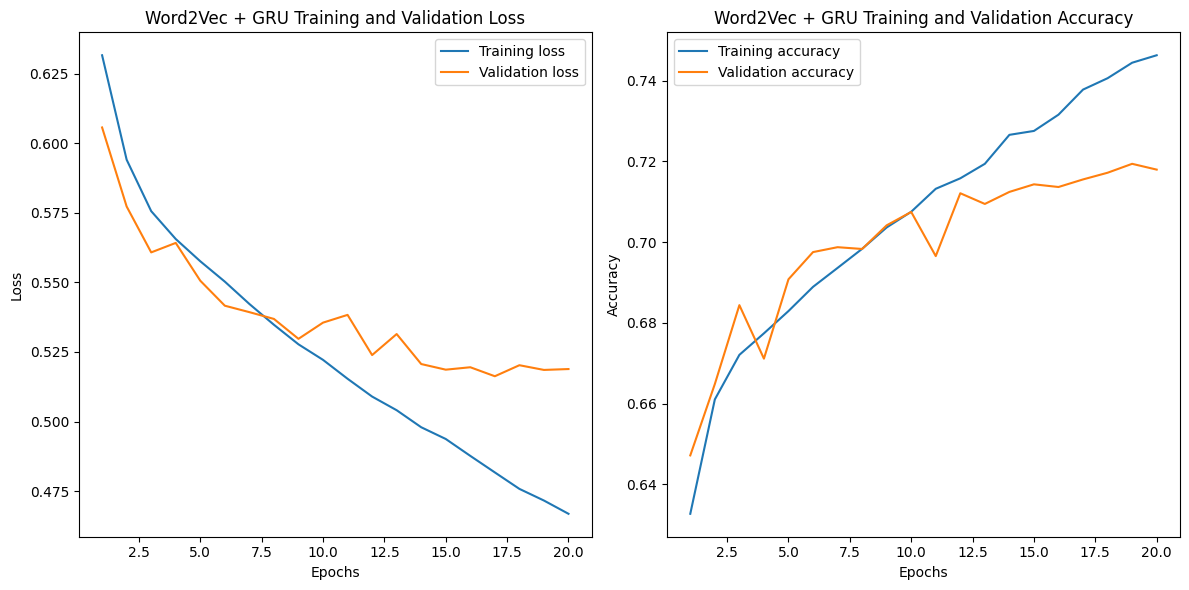

In [85]:
acc_w2v_gru = history_w2v_gru.history['accuracy']
val_acc_w2v_gru = history_w2v_gru.history['val_accuracy']
loss_w2v_gru = history_w2v_gru.history['loss']
val_loss_w2v_gru = history_w2v_gru.history['val_loss']

epochs_w2v_gru = range(1, len(acc_w2v_gru) + 1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_w2v_gru, loss_w2v_gru, label='Training loss')
plt.plot(epochs_w2v_gru, val_loss_w2v_gru, label='Validation loss')
plt.title('Word2Vec + GRU Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_w2v_gru, acc_w2v_gru, label='Training accuracy')
plt.plot(epochs_w2v_gru, val_acc_w2v_gru, label='Validation accuracy')
plt.title('Word2Vec + GRU Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

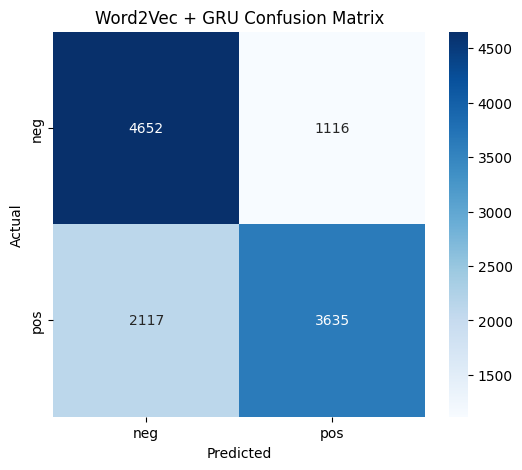

In [86]:
cm_w2v_gru = confusion_matrix(y_test, y_pred_w2v_gru)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_w2v_gru,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LB.classes_,
    yticklabels=LB.classes_
)

plt.title("Word2Vec + GRU Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## GloVe Embeddings

To use GloVe embeddings, you'll need a pre-trained Arabic GloVe model. You can often find these from academic projects or public datasets. As an example, a common source is the AraVec project or similar. You might need to download and extract a file like `glove_model.txt`.

Please ensure you have downloaded your preferred Arabic GloVe embedding file and update the `glove_file_path` variable below to its correct location. If the file is not found, a random embedding matrix will be used as a fallback, which will likely result in lower performance.

In [114]:
# Path to your GloVe embedding file (e.g., 'path/to/arabic_glove.txt')
glove_file_path = "arabic_glove.txt" # <--- UPDATE THIS PATH
glove_embedding_dim = 100 # Match the dimensionality of your GloVe vectors

glove_embeddings_index = {}
try:
    with open(glove_file_path, encoding="utf-8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            glove_embeddings_index[word] = coefs
    print(f"Found {len(glove_embeddings_index)} word vectors for GloVe.")

    glove_embedding_matrix = np.zeros((vocab_size + 1, glove_embedding_dim))
    for word, i in word_index.items():
        if i > vocab_size:
            continue
        embedding_vector = glove_embeddings_index.get(word)
        if embedding_vector is not None:
            glove_embedding_matrix[i] = embedding_vector
        else:
            # Words not found in embedding index will be all zeros
            pass
    print(f"GloVe embedding matrix shape: {glove_embedding_matrix.shape}")

except FileNotFoundError:
    print(f"GloVe embedding file not found at {glove_file_path}. Please download it and update the path.")
    # Fallback to random initialization if file not found
    glove_embedding_matrix = np.random.rand(vocab_size + 1, glove_embedding_dim) * 2 - 1
    print("Initializing GloVe embedding matrix with random values as a fallback.")
except Exception as e:
    print(f"Error loading GloVe embeddings: {e}")
    glove_embedding_matrix = np.random.rand(vocab_size + 1, glove_embedding_dim) * 2 - 1
    print("Initializing GloVe embedding matrix with random values as a fallback.")

GloVe embedding file not found at arabic_glove.txt. Please download it and update the path.
Initializing GloVe embedding matrix with random values as a fallback.


### GloVe + Simple RNN

In [115]:
model_glove_rnn = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(input_shape,)),
    tf.keras.layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=glove_embedding_dim,
        weights=[glove_embedding_matrix],
        trainable=False # Use pre-trained embeddings as-is
    ),
    tf.keras.layers.SimpleRNN(64),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_glove_rnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print(model_glove_rnn.summary())

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 25, 100)        │     6,576,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,587,525 (25.13 MB)

 Trainable params: 10,625 (41.50 KB)

 Non-trainable params: 6,576,900 (25.09 MB)

None


In [116]:
checkpoint_glove_rnn = ModelCheckpoint(
    "best_model_glove_rnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop_glove_rnn = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_glove_rnn = model_glove_rnn.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint_glove_rnn, early_stop_glove_rnn]
)

Epoch 1/100
563/566 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5168 - loss: 0.7118
Epoch 1: val_accuracy improved from None to 0.57283, saving model to best_model_glove_rnn.keras

Epoch 1: finished saving model to best_model_glove_rnn.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5327 - loss: 0.6971 - val_accuracy: 0.5728 - val_loss: 0.6609
Epoch 2/100
564/566 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5870 - loss: 0.6582
Epoch 2: val_accuracy improved from 0.57283 to 0.59923, saving model to best_model_glove_rnn.keras

Epoch 2: finished saving model to best_model_glove_rnn.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.5928 - loss: 0.6514 - val_accuracy: 0.5992 - val_loss: 0.6399
Epoch 3/100
563/566 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6277 - loss: 0.6220
Epoch 3: val_accuracy improved from 0.59923 to 0.61800, saving model to best_model_glove_rnn.keras

Epoch 3: finished saving model to best_model_glove_rnn.keras
566/566 ━━━━━━━━━━━━━━━

In [117]:
best_model_glove_rnn = tf.keras.models.load_model("best_model_glove_rnn.keras")

y_pred_prob_glove_rnn = best_model_glove_rnn.predict(X_test)
y_pred_glove_rnn = (y_pred_prob_glove_rnn > 0.5).astype(int).flatten()

print("GloVe + Simple RNN Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_glove_rnn,
        target_names=LB.classes_
    )
)

print("GloVe + Simple RNN Test Accuracy:", accuracy_score(y_test, y_pred_glove_rnn))

360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
GloVe + Simple RNN Classification Report:
              precision    recall  f1-score   support

         neg       0.65      0.72      0.68      5768
         pos       0.68      0.61      0.64      5752

    accuracy                           0.66     11520
   macro avg       0.67      0.66      0.66     11520
weighted avg       0.67      0.66      0.66     11520

GloVe + Simple RNN Test Accuracy: 0.6642361111111111


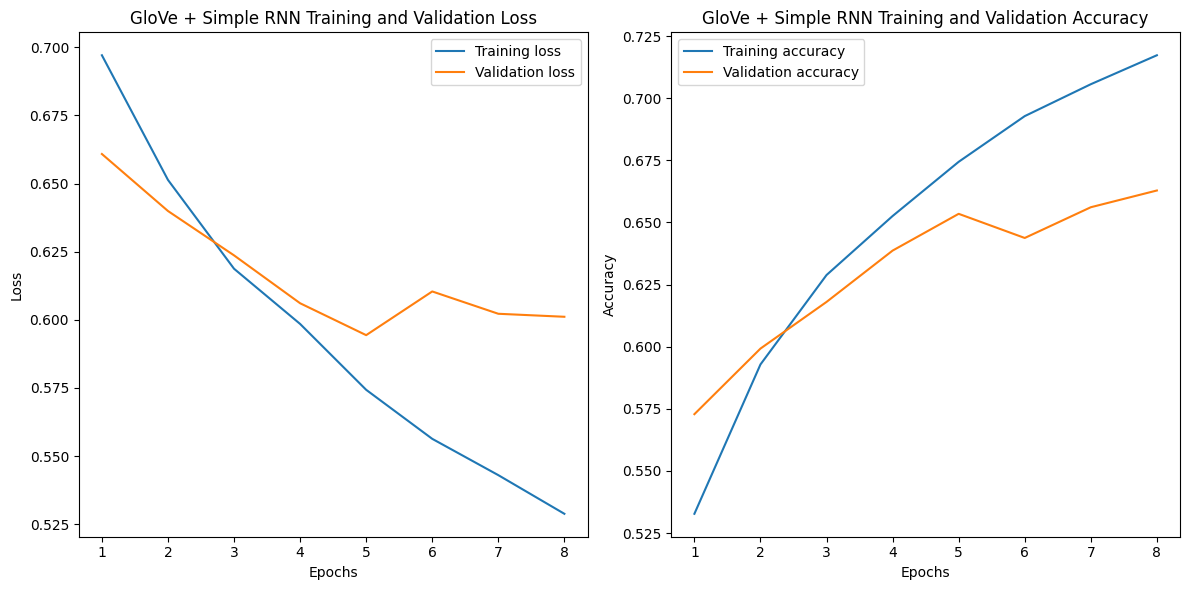

In [118]:
acc_glove_rnn = history_glove_rnn.history['accuracy']
val_acc_glove_rnn = history_glove_rnn.history['val_accuracy']
loss_glove_rnn = history_glove_rnn.history['loss']
val_loss_glove_rnn = history_glove_rnn.history['val_loss']

epochs_glove_rnn = range(1, len(acc_glove_rnn) + 1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_glove_rnn, loss_glove_rnn, label='Training loss')
plt.plot(epochs_glove_rnn, val_loss_glove_rnn, label='Validation loss')
plt.title('GloVe + Simple RNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_glove_rnn, acc_glove_rnn, label='Training accuracy')
plt.plot(epochs_glove_rnn, val_acc_glove_rnn, label='Validation accuracy')
plt.title('GloVe + Simple RNN Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

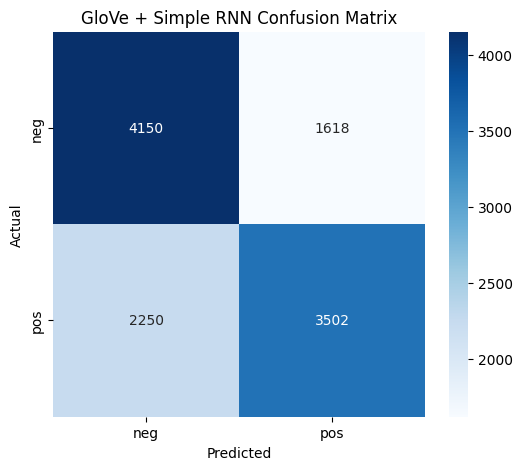

In [119]:
cm_glove_rnn = confusion_matrix(y_test, y_pred_glove_rnn)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_glove_rnn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LB.classes_,
    yticklabels=LB.classes_
)

plt.title("GloVe + Simple RNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### GloVe + LSTM

In [120]:
model_glove_lstm = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(input_shape,)),
    tf.keras.layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=glove_embedding_dim,
        weights=[glove_embedding_matrix],
        trainable=False
    ),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_glove_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print(model_glove_lstm.summary())

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 25, 100)        │     6,576,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,619,205 (25.25 MB)

 Trainable params: 42,305 (165.25 KB)

 Non-trainable params: 6,576,900 (25.09 MB)

None


In [121]:
checkpoint_glove_lstm = ModelCheckpoint(
    "best_model_glove_lstm.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop_glove_lstm = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_glove_lstm = model_glove_lstm.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint_glove_lstm, early_stop_glove_lstm]
)

Epoch 1/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5113 - loss: 0.6995
Epoch 1: val_accuracy improved from None to 0.63744, saving model to best_model_glove_lstm.keras

Epoch 1: finished saving model to best_model_glove_lstm.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5482 - loss: 0.6813 - val_accuracy: 0.6374 - val_loss: 0.6285
Epoch 2/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6528 - loss: 0.6096
Epoch 2: val_accuracy improved from 0.63744 to 0.69332, saving model to best_model_glove_lstm.keras

Epoch 2: finished saving model to best_model_glove_lstm.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.6673 - loss: 0.5946 - val_accuracy: 0.6933 - val_loss: 0.5640
Epoch 3/100
565/566 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7268 - loss: 0.5272
Epoch 3: val_accuracy improved from 0.69332 to 0.71728, saving model to best_model_glove_lstm.keras

Epoch 3: finished saving model to best_model_glove_lstm.keras
566/566 ━━━━

In [122]:
best_model_glove_lstm = tf.keras.models.load_model("best_model_glove_lstm.keras")

y_pred_prob_glove_lstm = best_model_glove_lstm.predict(X_test)
y_pred_glove_lstm = (y_pred_prob_glove_lstm > 0.5).astype(int).flatten()

print("GloVe + LSTM Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_glove_lstm,
        target_names=LB.classes_
    )
)

print("GloVe + LSTM Test Accuracy:", accuracy_score(y_test, y_pred_glove_lstm))

360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
GloVe + LSTM Classification Report:
              precision    recall  f1-score   support

         neg       0.71      0.83      0.76      5768
         pos       0.80      0.65      0.72      5752

    accuracy                           0.74     11520
   macro avg       0.75      0.74      0.74     11520
weighted avg       0.75      0.74      0.74     11520

GloVe + LSTM Test Accuracy: 0.7427951388888889


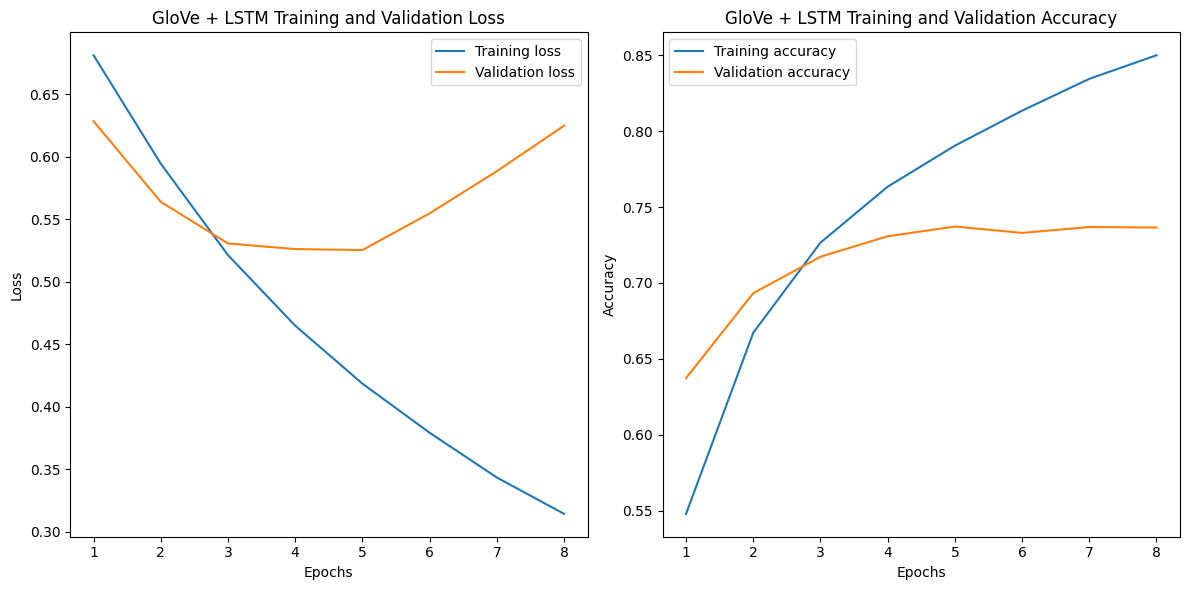

In [123]:
acc_glove_lstm = history_glove_lstm.history['accuracy']
val_acc_glove_lstm = history_glove_lstm.history['val_accuracy']
loss_glove_lstm = history_glove_lstm.history['loss']
val_loss_glove_lstm = history_glove_lstm.history['val_loss']

epochs_glove_lstm = range(1, len(acc_glove_lstm) + 1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_glove_lstm, loss_glove_lstm, label='Training loss')
plt.plot(epochs_glove_lstm, val_loss_glove_lstm, label='Validation loss')
plt.title('GloVe + LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_glove_lstm, acc_glove_lstm, label='Training accuracy')
plt.plot(epochs_glove_lstm, val_acc_glove_lstm, label='Validation accuracy')
plt.title('GloVe + LSTM Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

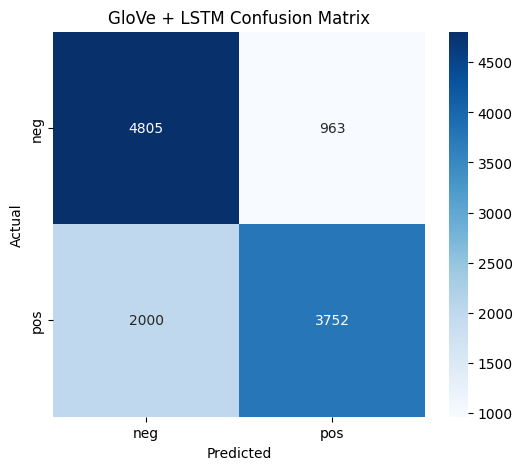

In [124]:
cm_glove_lstm = confusion_matrix(y_test, y_pred_glove_lstm)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_glove_lstm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LB.classes_,
    yticklabels=LB.classes_
)

plt.title("GloVe + LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### GloVe + GRU

In [125]:
model_glove_gru = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(input_shape,)),
    tf.keras.layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=glove_embedding_dim,
        weights=[glove_embedding_matrix],
        trainable=False
    ),
    tf.keras.layers.GRU(64),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_glove_gru.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print(model_glove_gru.summary())

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 25, 100)        │     6,576,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        31,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,608,837 (25.21 MB)

 Trainable params: 31,937 (124.75 KB)

 Non-trainable params: 6,576,900 (25.09 MB)

None


In [126]:
checkpoint_glove_gru = ModelCheckpoint(
    "best_model_glove_gru.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop_glove_gru = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_glove_gru = model_glove_gru.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint_glove_gru, early_stop_glove_gru]
)

Epoch 1/100
565/566 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5069 - loss: 0.7015
Epoch 1: val_accuracy improved from None to 0.62010, saving model to best_model_glove_gru.keras

Epoch 1: finished saving model to best_model_glove_gru.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.5381 - loss: 0.6839 - val_accuracy: 0.6201 - val_loss: 0.6322
Epoch 2/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6612 - loss: 0.5987
Epoch 2: val_accuracy improved from 0.62010 to 0.69740, saving model to best_model_glove_gru.keras

Epoch 2: finished saving model to best_model_glove_gru.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.6788 - loss: 0.5778 - val_accuracy: 0.6974 - val_loss: 0.5522
Epoch 3/100
564/566 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7321 - loss: 0.5125
Epoch 3: val_accuracy improved from 0.69740 to 0.71949, saving model to best_model_glove_gru.keras

Epoch 3: finished saving model to best_model_glove_gru.keras
566/566 ━━━━━━━━━━

In [127]:
best_model_glove_gru = tf.keras.models.load_model("best_model_glove_gru.keras")

y_pred_prob_glove_gru = best_model_glove_gru.predict(X_test)
y_pred_glove_gru = (y_pred_prob_glove_gru > 0.5).astype(int).flatten()

print("GloVe + GRU Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_glove_gru,
        target_names=LB.classes_
    )
)

print("GloVe + GRU Test Accuracy:", accuracy_score(y_test, y_pred_glove_gru))

360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
GloVe + GRU Classification Report:
              precision    recall  f1-score   support

         neg       0.71      0.84      0.77      5768
         pos       0.80      0.65      0.72      5752

    accuracy                           0.75     11520
   macro avg       0.75      0.75      0.74     11520
weighted avg       0.75      0.75      0.74     11520

GloVe + GRU Test Accuracy: 0.7456597222222222


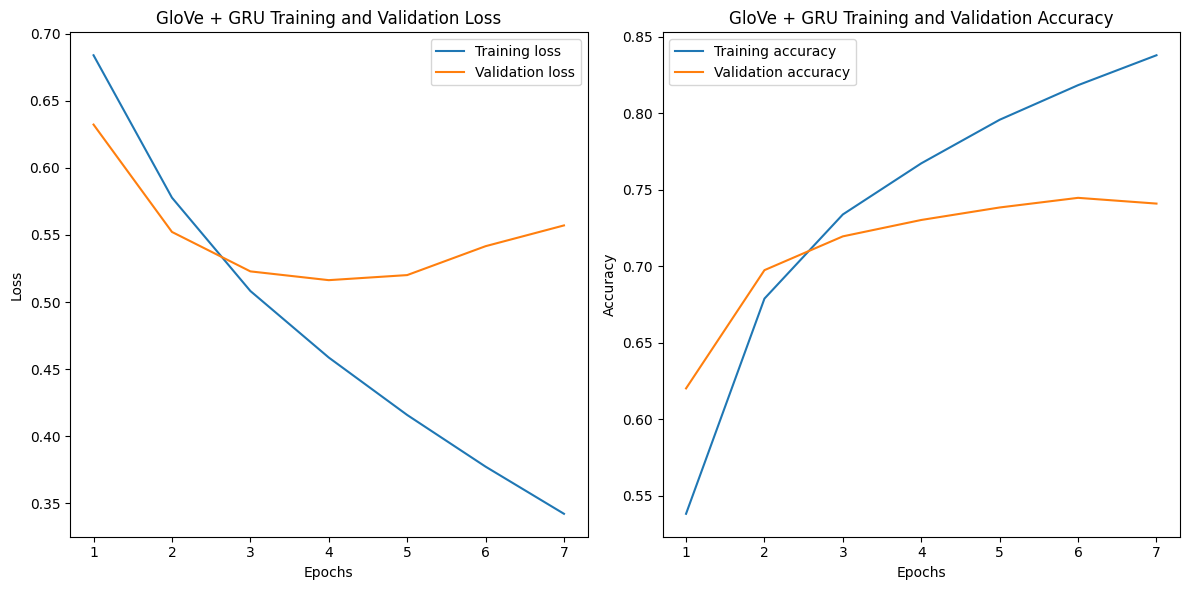

In [128]:
acc_glove_gru = history_glove_gru.history['accuracy']
val_acc_glove_gru = history_glove_gru.history['val_accuracy']
loss_glove_gru = history_glove_gru.history['loss']
val_loss_glove_gru = history_glove_gru.history['val_loss']

epochs_glove_gru = range(1, len(acc_glove_gru) + 1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_glove_gru, loss_glove_gru, label='Training loss')
plt.plot(epochs_glove_gru, val_loss_glove_gru, label='Validation loss')
plt.title('GloVe + GRU Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_glove_gru, acc_glove_gru, label='Training accuracy')
plt.plot(epochs_glove_gru, val_acc_glove_gru, label='Validation accuracy')
plt.title('GloVe + GRU Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

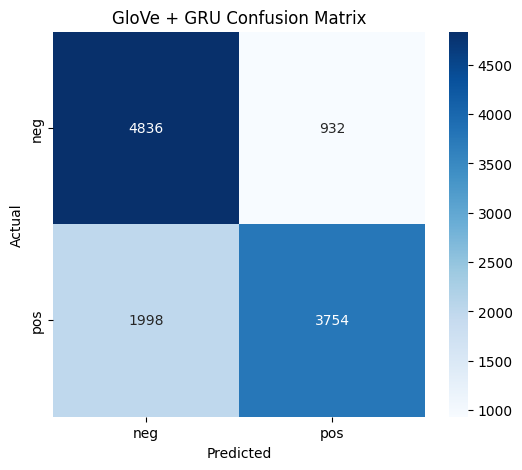

In [129]:
cm_glove_gru = confusion_matrix(y_test, y_pred_glove_gru)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_glove_gru,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LB.classes_,
    yticklabels=LB.classes_
)

plt.title("GloVe + GRU Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## FastText Embeddings

Similar to GloVe, you'll need a pre-trained FastText model for Arabic. FastText models often come in `.bin` or `.vec` formats. You can download pre-trained FastText models directly from the official FastText website (e.g., `cc.ar.300.vec` for Arabic).  Please ensure you have downloaded your FastText embedding file and update the `fasttext_file_path` variable below to its correct location.

In [130]:
# Install fasttext library if not already installed
!pip install fasttext

import fasttext

# Path to your FastText embedding file (e.g., 'path/to/cc.ar.300.vec')
fasttext_file_path = "arabic_fasttext.vec" # <--- UPDATE THIS PATH
fasttext_embedding_dim = 100 # Adjust if your FastText model has a different dimension. Often 300.

fasttext_embeddings_index = {}
try:
    # FastText .vec files are similar to GloVe in format
    with open(fasttext_file_path, encoding="utf-8") as f:
        # Skip the first line which usually contains vocab_size and embedding_dim
        next(f)
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            fasttext_embeddings_index[word] = coefs
    print(f"Found {len(fasttext_embeddings_index)} word vectors for FastText.")

    fasttext_embedding_matrix = np.zeros((vocab_size + 1, fasttext_embedding_dim))
    for word, i in word_index.items():
        if i > vocab_size:
            continue
        embedding_vector = fasttext_embeddings_index.get(word)
        if embedding_vector is not None:
            fasttext_embedding_matrix[i] = embedding_vector
        else:
            # Words not found in embedding index will be all zeros
            pass
    print(f"FastText embedding matrix shape: {fasttext_embedding_matrix.shape}")

except FileNotFoundError:
    print(f"FastText embedding file not found at {fasttext_file_path}. Please download it and update the path.")
    # Fallback to random initialization if file not found
    fasttext_embedding_matrix = np.random.rand(vocab_size + 1, fasttext_embedding_dim) * 2 - 1
    print("Initializing FastText embedding matrix with random values as a fallback.")
except Exception as e:
    print(f"Error loading FastText embeddings: {e}")
    fasttext_embedding_matrix = np.random.rand(vocab_size + 1, fasttext_embedding_dim) * 2 - 1
    print("Initializing FastText embedding matrix with random values as a fallback.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 3.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4653922 sha256=c6eb940a6b68e78474ab681191968bda7a8cb97f9bf6d5e46824bc2dd0789db9
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext
FastText embedding file not found at arabic_fasttext.vec. Please download it and update the path.
Initializing FastText embedding matrix with random values as a fallback.


### FastText + Simple RNN

In [131]:
model_fasttext_rnn = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(input_shape,)),
    tf.keras.layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=fasttext_embedding_dim,
        weights=[fasttext_embedding_matrix],
        trainable=False
    ),
    tf.keras.layers.SimpleRNN(64),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_fasttext_rnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print(model_fasttext_rnn.summary())

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 25, 100)        │     6,576,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,587,525 (25.13 MB)

 Trainable params: 10,625 (41.50 KB)

 Non-trainable params: 6,576,900 (25.09 MB)

None


In [132]:
checkpoint_fasttext_rnn = ModelCheckpoint(
    "best_model_fasttext_rnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop_fasttext_rnn = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_fasttext_rnn = model_fasttext_rnn.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint_fasttext_rnn, early_stop_fasttext_rnn]
)

Epoch 1/100
563/566 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5044 - loss: 0.7162
Epoch 1: val_accuracy improved from None to 0.57990, saving model to best_model_fasttext_rnn.keras

Epoch 1: finished saving model to best_model_fasttext_rnn.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.5269 - loss: 0.6977 - val_accuracy: 0.5799 - val_loss: 0.6584
Epoch 2/100
560/566 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5892 - loss: 0.6567
Epoch 2: val_accuracy improved from 0.57990 to 0.60994, saving model to best_model_fasttext_rnn.keras

Epoch 2: finished saving model to best_model_fasttext_rnn.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.5961 - loss: 0.6518 - val_accuracy: 0.6099 - val_loss: 0.6357
Epoch 3/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6366 - loss: 0.6207
Epoch 3: val_accuracy improved from 0.60994 to 0.62684, saving model to best_model_fasttext_rnn.keras

Epoch 3: finished saving model to best_model_fasttext_rnn.keras
5

In [133]:
best_model_fasttext_rnn = tf.keras.models.load_model("best_model_fasttext_rnn.keras")

y_pred_prob_fasttext_rnn = best_model_fasttext_rnn.predict(X_test)
y_pred_fasttext_rnn = (y_pred_prob_fasttext_rnn > 0.5).astype(int).flatten()

print("FastText + Simple RNN Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_fasttext_rnn,
        target_names=LB.classes_
    )
)

print("FastText + Simple RNN Test Accuracy:", accuracy_score(y_test, y_pred_fasttext_rnn))

360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
FastText + Simple RNN Classification Report:
              precision    recall  f1-score   support

         neg       0.66      0.72      0.68      5768
         pos       0.69      0.62      0.65      5752

    accuracy                           0.67     11520
   macro avg       0.67      0.67      0.67     11520
weighted avg       0.67      0.67      0.67     11520

FastText + Simple RNN Test Accuracy: 0.66953125


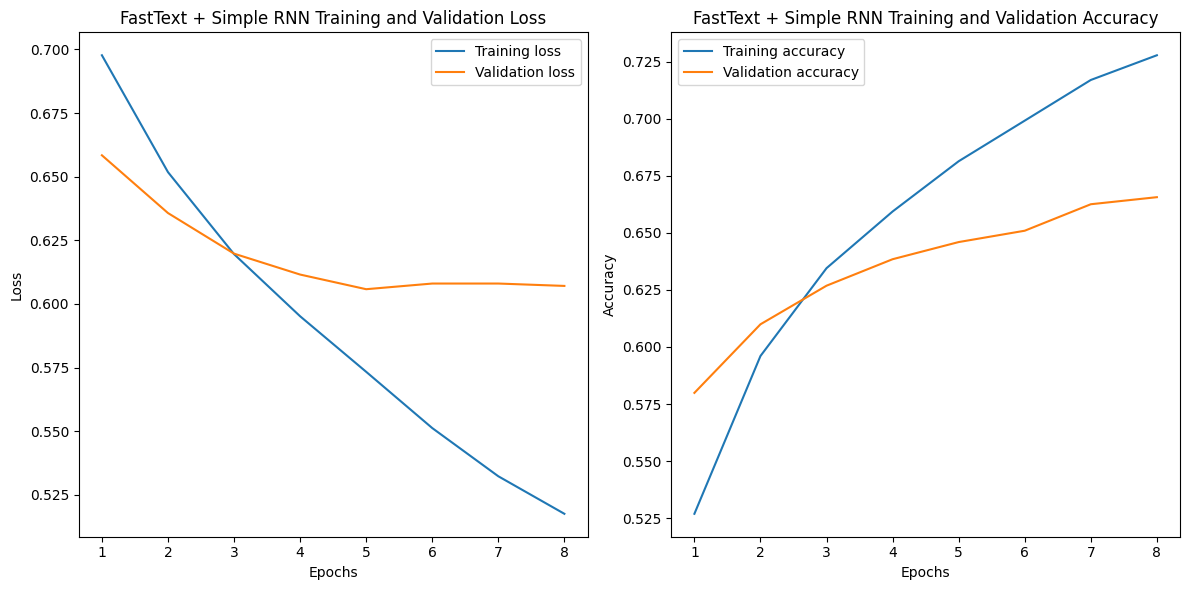

In [134]:
acc_fasttext_rnn = history_fasttext_rnn.history['accuracy']
val_acc_fasttext_rnn = history_fasttext_rnn.history['val_accuracy']
loss_fasttext_rnn = history_fasttext_rnn.history['loss']
val_loss_fasttext_rnn = history_fasttext_rnn.history['val_loss']

epochs_fasttext_rnn = range(1, len(acc_fasttext_rnn) + 1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_fasttext_rnn, loss_fasttext_rnn, label='Training loss')
plt.plot(epochs_fasttext_rnn, val_loss_fasttext_rnn, label='Validation loss')
plt.title('FastText + Simple RNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_fasttext_rnn, acc_fasttext_rnn, label='Training accuracy')
plt.plot(epochs_fasttext_rnn, val_acc_fasttext_rnn, label='Validation accuracy')
plt.title('FastText + Simple RNN Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

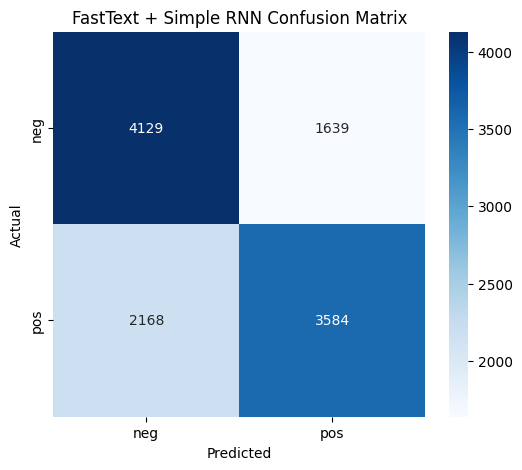

In [135]:
cm_fasttext_rnn = confusion_matrix(y_test, y_pred_fasttext_rnn)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_fasttext_rnn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LB.classes_,
    yticklabels=LB.classes_
)

plt.title("FastText + Simple RNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### FastText + LSTM

In [136]:
model_fasttext_lstm = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(input_shape,)),
    tf.keras.layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=fasttext_embedding_dim,
        weights=[fasttext_embedding_matrix],
        trainable=False
    ),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_fasttext_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print(model_fasttext_lstm.summary())

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ (None, 25, 100)        │     6,576,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,619,205 (25.25 MB)

 Trainable params: 42,305 (165.25 KB)

 Non-trainable params: 6,576,900 (25.09 MB)

None


In [137]:
checkpoint_fasttext_lstm = ModelCheckpoint(
    "best_model_fasttext_lstm.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop_fasttext_lstm = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_fasttext_lstm = model_fasttext_lstm.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint_fasttext_lstm, early_stop_fasttext_lstm]
)

Epoch 1/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5100 - loss: 0.7003
Epoch 1: val_accuracy improved from None to 0.61756, saving model to best_model_fasttext_lstm.keras

Epoch 1: finished saving model to best_model_fasttext_lstm.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.5356 - loss: 0.6880 - val_accuracy: 0.6176 - val_loss: 0.6453
Epoch 2/100
564/566 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6390 - loss: 0.6283
Epoch 2: val_accuracy improved from 0.61756 to 0.68426, saving model to best_model_fasttext_lstm.keras

Epoch 2: finished saving model to best_model_fasttext_lstm.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - accuracy: 0.6566 - loss: 0.6078 - val_accuracy: 0.6843 - val_loss: 0.5751
Epoch 3/100
565/566 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7168 - loss: 0.5345
Epoch 3: val_accuracy improved from 0.68426 to 0.71408, saving model to best_model_fasttext_lstm.keras

Epoch 3: finished saving model to best_model_fasttext_lstm.

In [138]:
best_model_fasttext_lstm = tf.keras.models.load_model("best_model_fasttext_lstm.keras")

y_pred_prob_fasttext_lstm = best_model_fasttext_lstm.predict(X_test)
y_pred_fasttext_lstm = (y_pred_prob_fasttext_lstm > 0.5).astype(int).flatten()

print("FastText + LSTM Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_fasttext_lstm,
        target_names=LB.classes_
    )
)

print("FastText + LSTM Test Accuracy:", accuracy_score(y_test, y_pred_fasttext_lstm))

360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
FastText + LSTM Classification Report:
              precision    recall  f1-score   support

         neg       0.72      0.80      0.76      5768
         pos       0.78      0.69      0.73      5752

    accuracy                           0.75     11520
   macro avg       0.75      0.75      0.74     11520
weighted avg       0.75      0.75      0.74     11520

FastText + LSTM Test Accuracy: 0.7455729166666667


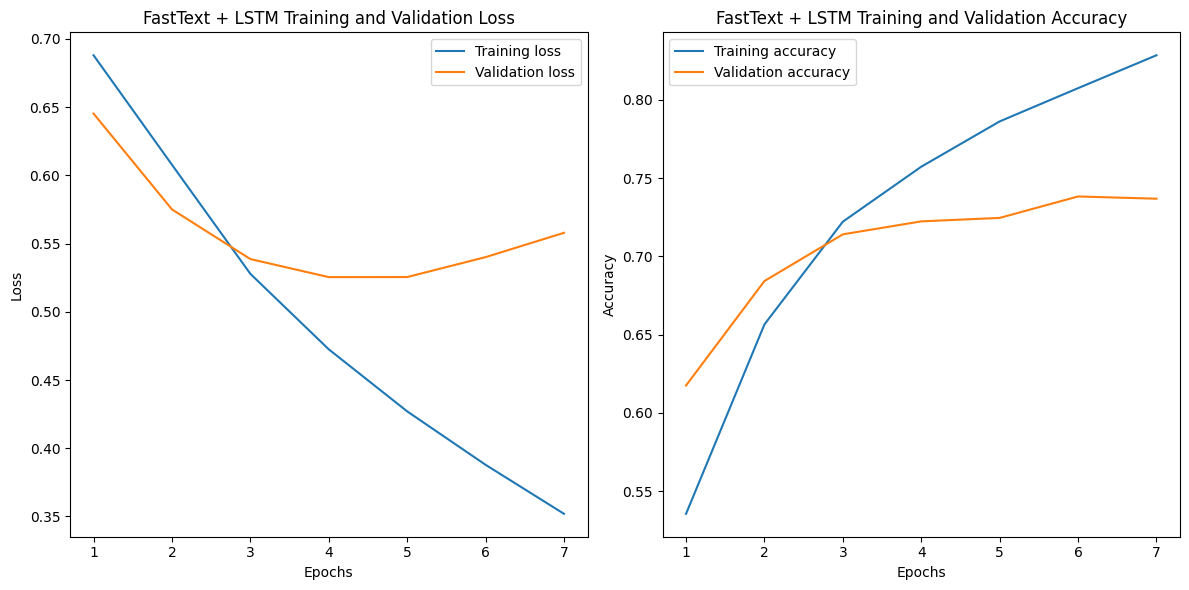

In [139]:
acc_fasttext_lstm = history_fasttext_lstm.history['accuracy']
val_acc_fasttext_lstm = history_fasttext_lstm.history['val_accuracy']
loss_fasttext_lstm = history_fasttext_lstm.history['loss']
val_loss_fasttext_lstm = history_fasttext_lstm.history['val_loss']

epochs_fasttext_lstm = range(1, len(acc_fasttext_lstm) + 1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_fasttext_lstm, loss_fasttext_lstm, label='Training loss')
plt.plot(epochs_fasttext_lstm, val_loss_fasttext_lstm, label='Validation loss')
plt.title('FastText + LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_fasttext_lstm, acc_fasttext_lstm, label='Training accuracy')
plt.plot(epochs_fasttext_lstm, val_acc_fasttext_lstm, label='Validation accuracy')
plt.title('FastText + LSTM Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

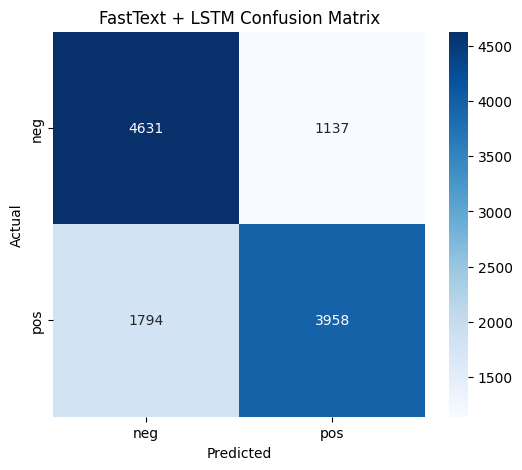

In [140]:
cm_fasttext_lstm = confusion_matrix(y_test, y_pred_fasttext_lstm)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_fasttext_lstm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LB.classes_,
    yticklabels=LB.classes_
)

plt.title("FastText + LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### FastText + GRU

In [141]:
model_fasttext_gru = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(input_shape,)),
    tf.keras.layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=fasttext_embedding_dim,
        weights=[fasttext_embedding_matrix],
        trainable=False
    ),
    tf.keras.layers.GRU(64),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_fasttext_gru.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print(model_fasttext_gru.summary())

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 25, 100)        │     6,576,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        31,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,608,837 (25.21 MB)

 Trainable params: 31,937 (124.75 KB)

 Non-trainable params: 6,576,900 (25.09 MB)

None


In [142]:
checkpoint_fasttext_gru = ModelCheckpoint(
    "best_model_fasttext_gru.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop_fasttext_gru = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_fasttext_gru = model_fasttext_gru.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint_fasttext_gru, early_stop_fasttext_gru]
)

Epoch 1/100
565/566 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5198 - loss: 0.7005
Epoch 1: val_accuracy improved from None to 0.63821, saving model to best_model_fasttext_gru.keras

Epoch 1: finished saving model to best_model_fasttext_gru.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.5465 - loss: 0.6807 - val_accuracy: 0.6382 - val_loss: 0.6151
Epoch 2/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6723 - loss: 0.5861
Epoch 2: val_accuracy improved from 0.63821 to 0.68559, saving model to best_model_fasttext_gru.keras

Epoch 2: finished saving model to best_model_fasttext_gru.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.6857 - loss: 0.5705 - val_accuracy: 0.6856 - val_loss: 0.5627
Epoch 3/100
564/566 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7390 - loss: 0.5007
Epoch 3: val_accuracy improved from 0.68559 to 0.69895, saving model to best_model_fasttext_gru.keras

Epoch 3: finished saving model to best_model_fasttext_gru.keras


In [143]:
best_model_fasttext_gru = tf.keras.models.load_model("best_model_fasttext_gru.keras")

y_pred_prob_fasttext_gru = best_model_fasttext_gru.predict(X_test)
y_pred_fasttext_gru = (y_pred_prob_fasttext_gru > 0.5).astype(int).flatten()

print("FastText + GRU Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_fasttext_gru,
        target_names=LB.classes_
    )
)

print("FastText + GRU Test Accuracy:", accuracy_score(y_test, y_pred_fasttext_gru))

360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
FastText + GRU Classification Report:
              precision    recall  f1-score   support

         neg       0.73      0.79      0.76      5768
         pos       0.77      0.70      0.73      5752

    accuracy                           0.75     11520
   macro avg       0.75      0.75      0.74     11520
weighted avg       0.75      0.75      0.74     11520

FastText + GRU Test Accuracy: 0.7452256944444444


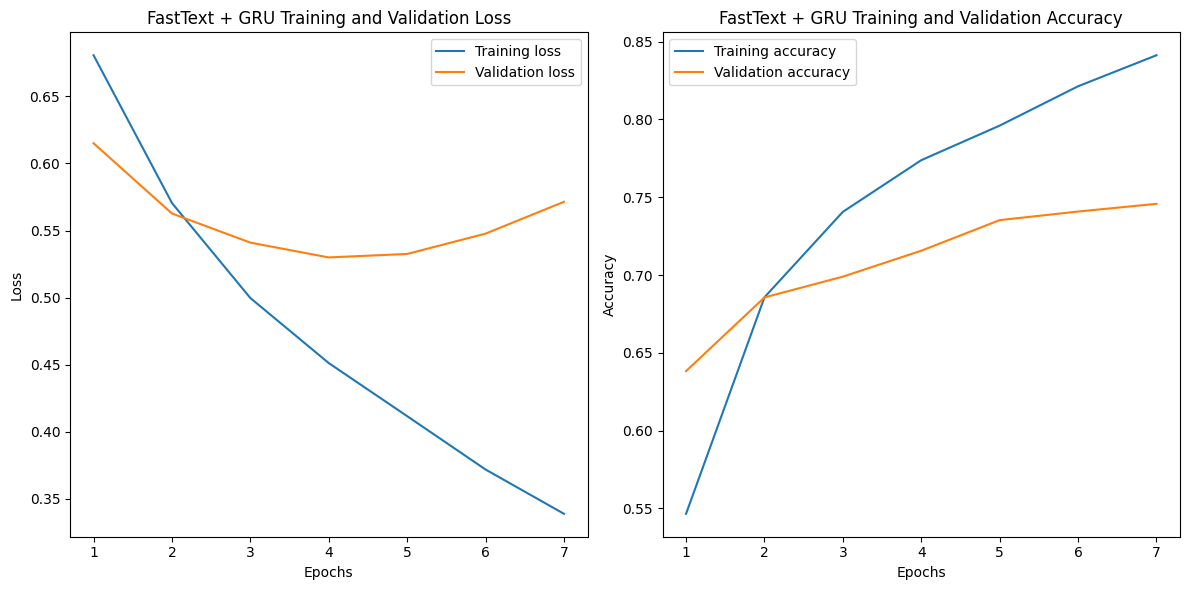

In [144]:
acc_fasttext_gru = history_fasttext_gru.history['accuracy']
val_acc_fasttext_gru = history_fasttext_gru.history['val_accuracy']
loss_fasttext_gru = history_fasttext_gru.history['loss']
val_loss_fasttext_gru = history_fasttext_gru.history['val_loss']

epochs_fasttext_gru = range(1, len(acc_fasttext_gru) + 1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_fasttext_gru, loss_fasttext_gru, label='Training loss')
plt.plot(epochs_fasttext_gru, val_loss_fasttext_gru, label='Validation loss')
plt.title('FastText + GRU Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_fasttext_gru, acc_fasttext_gru, label='Training accuracy')
plt.plot(epochs_fasttext_gru, val_acc_fasttext_gru, label='Validation accuracy')
plt.title('FastText + GRU Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

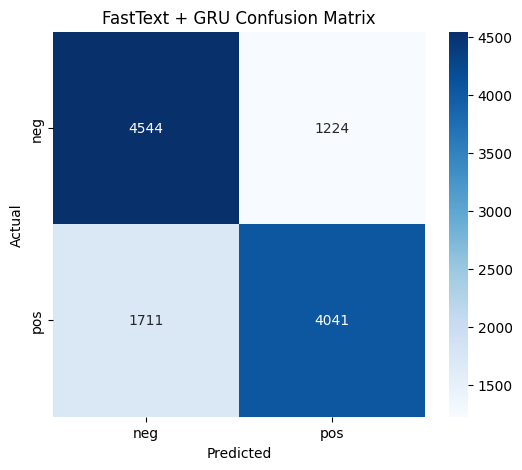

In [145]:
cm_fasttext_gru = confusion_matrix(y_test, y_pred_fasttext_gru)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_fasttext_gru,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LB.classes_,
    yticklabels=LB.classes_
)

plt.title("FastText + GRU Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Consolidated Model Comparison


--- Model Accuracy Comparison ---


,Accuracy
GRU,0.765799
RNN,0.755729
GloVe + GRU,0.745660
FastText + LSTM,0.745573
FastText + GRU,0.745226
GloVe + LSTM,0.742795
LSTM,0.737587
Word2Vec + GRU,0.719358
Word2Vec + LSTM,0.715017
Word2Vec + RNN,0.695660


/tmp/ipykernel_3161/393770871.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_comparison_df.index, y=model_comparison_df['Accuracy'], palette='viridis')


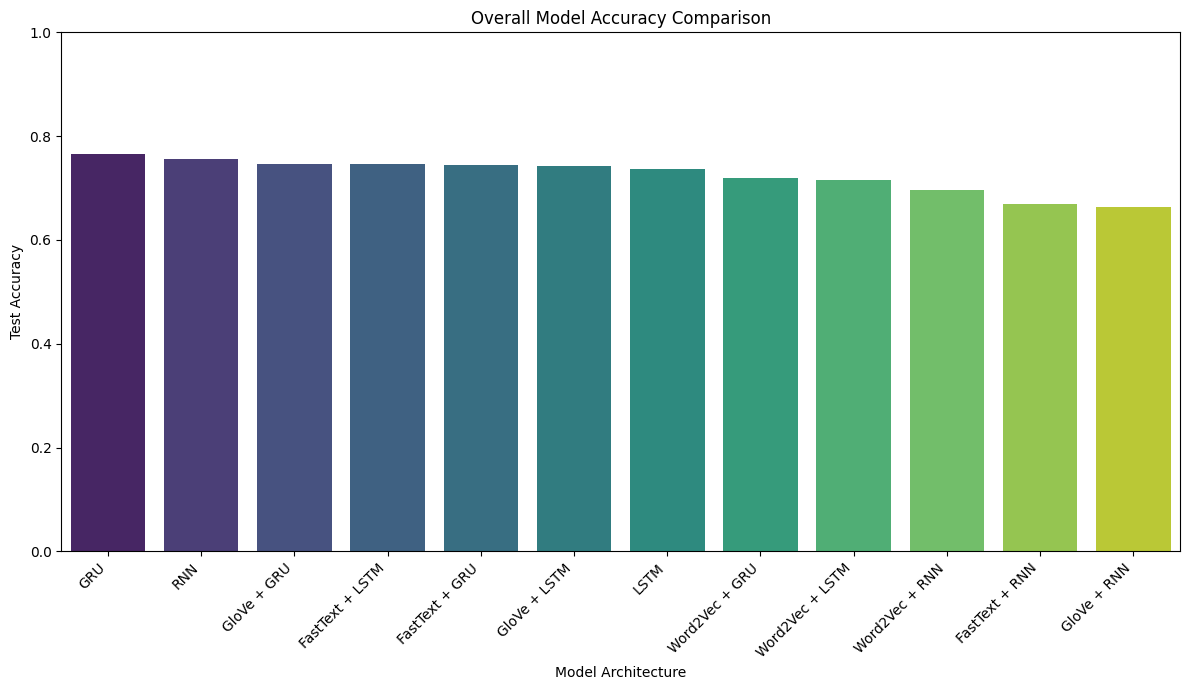

In [147]:
# Compile all model accuracies and losses for comparison

model_comparison_accuracy = {
    "RNN": accuracy_score(y_test, y_pred),
    "LSTM": accuracy_score(y_test, y_pred_lstm),
    "GRU": accuracy_score(y_test, y_pred_gru),
    "Word2Vec + RNN": accuracy_score(y_test, y_pred_w2v_rnn),
    "Word2Vec + LSTM": accuracy_score(y_test, y_pred_w2v_lstm),
    "Word2Vec + GRU": accuracy_score(y_test, y_pred_w2v_gru),
    "GloVe + RNN": accuracy_score(y_test, y_pred_glove_rnn),
    "GloVe + LSTM": accuracy_score(y_test, y_pred_glove_lstm),
    "GloVe + GRU": accuracy_score(y_test, y_pred_glove_gru),
    "FastText + RNN": accuracy_score(y_test, y_pred_fasttext_rnn),
    "FastText + LSTM": accuracy_score(y_test, y_pred_fasttext_lstm),
    "FastText + GRU": accuracy_score(y_test, y_pred_fasttext_gru)
}

model_comparison_df = pd.DataFrame.from_dict(model_comparison_accuracy, orient='index', columns=['Accuracy'])
model_comparison_df = model_comparison_df.sort_values(by='Accuracy', ascending=False)

print("\n--- Model Accuracy Comparison ---")
display(model_comparison_df)

# Visualize comparison
plt.figure(figsize=(12, 7))
sns.barplot(x=model_comparison_df.index, y=model_comparison_df['Accuracy'], palette='viridis')
plt.title('Overall Model Accuracy Comparison')
plt.xlabel('Model Architecture')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.tight_layout()
plt.show()